# Sequential updating with IncrementalConditioner

In many applications, data arrives in **batches** rather than all at once. A sensor network reports readings every hour. A clinical trial enrolls patients in stages. An online retailer observes purchases day by day. In each case, we want to **update our beliefs incrementally** as new evidence arrives, carrying the posterior from one batch forward as the prior for the next.

ProbPipe's transition framework builds on the same primitives you already know — `condition_on`, `from_distribution`, the converter registry, and the inference method registry — and adds a thin iteration layer on top.

### The core abstraction

The central pattern is a **fold over distributions**. A *step function* takes the current distribution and an external input, and produces a new distribution:

```
       x₁            x₂            x₃
       │              │              │
       ▼              ▼              ▼
D₀ ─→ step ─→ D₁ ─→ step ─→ D₂ ─→ step ─→ D₃
```

Here `D₀` is the initial distribution (e.g., a prior), `x₁, x₂, x₃` are external inputs (e.g., data batches), and `step` is any callable `(Distribution, input) -> Distribution`. The `iterate` function folds the step over the inputs, producing the sequence `[D₀, D₁, D₂, D₃]`.

**Outline:**

1. [Problem setup](#1.-Problem-Setup)
2. [Single-batch updating: IncrementalConditioner](#2.-Single-Batch-Updating:-IncrementalConditioner)
3. [Multi-batch iteration: update_all and iterate](#3.-Multi-Batch-Iteration:-update_all-and-iterate)
4. [Keeping posteriors parametric: with_conversion](#4.-Keeping-Posteriors-Parametric:-with_conversion)
5. [Resampling degenerate particles: with_resampling](#5.-Resampling-Degenerate-Particles:-with_resampling)
6. [Custom step functions](#6.-Custom-Step-Functions)
7. [Callbacks and early stopping](#7.-Callbacks-and-Early-Stopping)
8. [Provenance tracking](#8.-Provenance-Tracking)
9. [Composing and nesting](#9.-Composing-and-Nesting)
10. [Summary](#10.-Summary)

## 1. Problem Setup

We estimate a 2-D mean vector $\boldsymbol{\mu}$ from noisy observations:

$$y_i \sim \mathcal{N}(\boldsymbol{\mu},\, I), \qquad \boldsymbol{\mu} \sim \mathcal{N}(\mathbf{0},\, 10\,I)$$

We generate 200 observations and split them into 4 batches of 50.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype.*float64.*")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    MultivariateNormal, EmpiricalDistribution,
    condition_on, from_distribution, mean, provenance_ancestors,
    sample as pp_sample,
    iterate, with_conversion, with_resampling,
    IncrementalConditioner,
)
from probpipe.modeling import Likelihood

rng = np.random.default_rng(42)

In [2]:
true_mu = jnp.array([2.0, -1.0])
y_all = jnp.array(rng.multivariate_normal(np.array(true_mu), np.eye(2), size=200))
batches = [y_all[i:i+50] for i in range(0, 200, 50)]

prior = MultivariateNormal(loc=jnp.zeros(2), cov=10.0 * jnp.eye(2), name="prior")

class GaussianLikelihood:
    def log_likelihood(self, params, data):
        residuals = jnp.asarray(data) - params[None, :]
        return -0.5 * jnp.sum(residuals ** 2)

likelihood = GaussianLikelihood()

print(f"True mu:    {true_mu}")
print(f"Batches:    {len(batches)} x {batches[0].shape[0]} observations")
print(f"Prior mean: {mean(prior)}")

True mu:    [ 2. -1.]
Batches:    4 x 50 observations
Prior mean: NumericRecord(mean=array(shape=(2,)))


### Conditioning function

By default, `condition_on` dispatches through the **inference method registry**, selecting an appropriate backend based on what the model supports. You can also provide your own conditioning function — ProbPipe's dispatch system is designed for this.

For this tutorial we use a fast analytic conditioner. In practice, `IncrementalConditioner(prior, likelihood)` dispatches to `condition_on` automatically.

In [3]:
def gaussian_conjugate_condition(model, data, **kwargs):
    """Conjugate Gaussian posterior (known unit variance)."""
    prior_dist = model["parameters"]
    prior_mean = mean(prior_dist)
    data = jnp.asarray(data)
    n = data.shape[0]
    prior_prec = jnp.linalg.inv(jnp.array([[10., 0.], [0., 10.]]))
    data_prec = n * jnp.eye(2)
    post_prec = prior_prec + data_prec
    post_cov = jnp.linalg.inv(post_prec)
    post_mean = post_cov @ (prior_prec @ prior_mean + data_prec @ jnp.mean(data, axis=0))
    key = jax.random.PRNGKey(hash(str(data[:3])) % (2**31))
    samples = jax.random.multivariate_normal(key, post_mean, post_cov, shape=(500,))
    return EmpiricalDistribution(samples, name="posterior")

---

## 2. Single-Batch Updating: IncrementalConditioner

`IncrementalConditioner` is the simplest way to do sequential updating. It maintains a **current posterior** (initially the prior) and provides `update()` to condition on one batch at a time.

In [4]:
conditioner = IncrementalConditioner(
    prior=prior,
    likelihood=likelihood,
    condition_fn=gaussian_conjugate_condition,
)

print(f"Initial: {mean(conditioner.curr_posterior)}")

for i, batch in enumerate(batches):
    posterior = conditioner.update(data=batch)
    print(f"After batch {i+1}: {mean(conditioner.curr_posterior)}")

print(f"\nTrue mu: {true_mu}")

Initial: NumericRecord(mean=array(shape=(2,)))


After batch 1: NumericRecord(mean=array(shape=(2,)))
After batch 2: NumericRecord(mean=array(shape=(2,)))


After batch 3: NumericRecord(mean=array(shape=(2,)))
After batch 4: NumericRecord(mean=array(shape=(2,)))

True mu: [ 2. -1.]


Each `update()` call returns the posterior and advances the internal state. The posterior from each step is automatically converted to support `log_prob` (via ProbPipe's converter registry) before it's used as the next prior.

---

## 3. Multi-Batch Iteration: `update_all` and `iterate`

When you have all batches upfront, `update_all` processes them in one call and returns the full sequence of distributions. It also updates the conditioner's state to the final posterior.

In [5]:
conditioner = IncrementalConditioner(
    prior=prior, likelihood=likelihood,
    condition_fn=gaussian_conjugate_condition,
)

dists = conditioner.update_all(data_batches=batches)

print(f"Sequence length: {len(dists)} (prior + {len(batches)} posteriors)")
print(f"Final mean:      {mean(dists[-1])}")
print(f"State updated:   {conditioner.curr_posterior is dists[-1]}")

Sequence length: 5 (prior + 4 posteriors)
Final mean:      NumericRecord(mean=array(shape=(2,)))
State updated:   True


Under the hood, `update_all` calls `iterate(self.step, self.curr_posterior, data_batches)`. The `.step` property exposes the step function directly, so you can call `iterate` yourself when you want functional composition with combinators (introduced below):

In [6]:
dists = iterate(conditioner.step, prior, batches)

print(f"Sequence length: {len(dists)}")
print(f"Final mean:      {mean(dists[-1])}")

Sequence length: 5
Final mean:      NumericRecord(mean=array(shape=(2,)))


---

## 4. Keeping Posteriors Parametric: `with_conversion`

Each conditioning step typically returns MCMC samples. But we often want the next prior to be parametric — a `MultivariateNormal` fit to those samples.

`with_conversion` wraps a step function to call ProbPipe's `from_distribution` after each step — the same conversion operation used throughout ProbPipe. The pre-conversion distribution is accessible via provenance (`dist.source.parents`).

  Step 0: NumericEmpiricalDistribution   -> MultivariateNormal
  Step 1: NumericEmpiricalDistribution   -> MultivariateNormal
  Step 2: NumericEmpiricalDistribution   -> MultivariateNormal
  Step 3: NumericEmpiricalDistribution   -> MultivariateNormal

All parametric: True


/var/folders/1w/v02h_t9j1d57gct5v3zvyklr0000gq/T/ipykernel_14286/2665669957.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  samples = np.array(pp_sample(dist, key=jax.random.PRNGKey(i), sample_shape=(500,)))


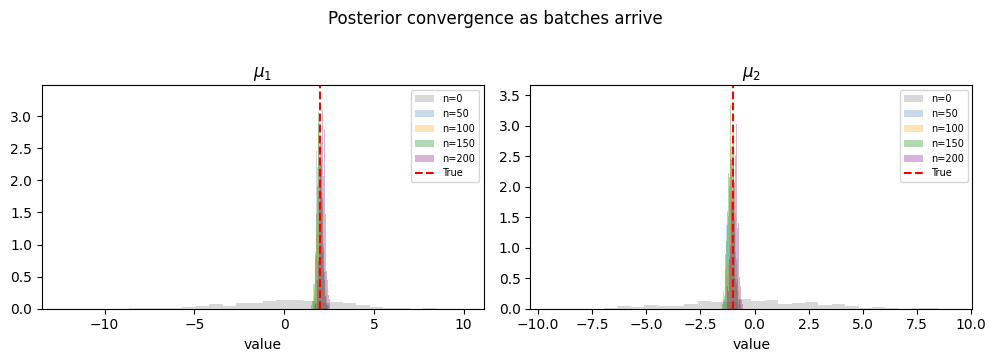

In [7]:
approx_step = with_conversion(conditioner.step, MultivariateNormal, name="posterior")
dists = iterate(approx_step, prior, batches)

for i, d in enumerate(dists[1:]):
    pre = d.source.parents[0]  # pre-conversion distribution via provenance
    print(f"  Step {i}: {type(pre).__name__:30s} -> {type(d).__name__}")

print(f"\nAll parametric: {all(isinstance(d, MultivariateNormal) for d in dists[1:])}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

colors = ['gray', 'steelblue', 'orange', 'green', 'purple']
for i, dist in enumerate(dists):
    n_seen = i * 50
    samples = np.array(pp_sample(dist, key=jax.random.PRNGKey(i), sample_shape=(500,)))
    ax1.hist(samples[:, 0], bins=30, density=True, alpha=0.3, color=colors[i], label=f'n={n_seen}')
    ax2.hist(samples[:, 1], bins=30, density=True, alpha=0.3, color=colors[i], label=f'n={n_seen}')

for ax, true_val in [(ax1, true_mu[0]), (ax2, true_mu[1])]:
    ax.axvline(float(true_val), color='red', linestyle='--', label=f'True')
    ax.set_xlabel('value')
    ax.legend(fontsize=7)

ax1.set_title(r'$\mu_1$')
ax2.set_title(r'$\mu_2$')
fig.suptitle('Posterior convergence as batches arrive', y=1.02)
plt.tight_layout()
plt.show()

---

## 5. Resampling Degenerate Particles: `with_resampling`

In **tempering** and **SMC**, particles carry importance weights that can degenerate — a few particles dominate while the rest carry negligible weight.

`with_resampling` monitors ESS after each step and resamples when `ESS/N` drops below a threshold. When resampling occurs, the pre-resampling ESS is stored in the resampled distribution's provenance metadata.

In [8]:
def tempering_step(dist, beta_increment):
    """Reweight particles by a tempered quadratic likelihood."""
    samples = dist.samples
    target = jnp.array([2.0, 2.0])
    log_lik = -0.5 * jnp.sum((samples - target) ** 2, axis=1)
    old_log_w = dist._w.log_normalized
    new_log_w = old_log_w + beta_increment * log_lik
    return EmpiricalDistribution(samples, log_weights=new_log_w)

key = jax.random.PRNGKey(0)
prior_samples = jax.random.normal(key, shape=(500, 2)) * 3.0
particles = EmpiricalDistribution(prior_samples, name="prior_particles")

betas = [0.2] * 5

# Without resampling
dists_no = iterate(tempering_step, particles, betas)

# With resampling
dists_yes = iterate(with_resampling(tempering_step, ess_threshold=0.5), particles, betas)

In [9]:
print("Without resampling:")
for i, d in enumerate(dists_no[1:]):
    ess = float(d.effective_sample_size)
    print(f"  Step {i}: ESS = {ess:5.1f} ({ess/500*100:2.0f}%)")

print("\nWith resampling (threshold = 50%):")
for i, d in enumerate(dists_yes[1:]):
    was_resampled = d.source is not None and d.source.operation == "resample"
    if was_resampled:
        pre_ess = d.source.metadata["ess"]
        print(f"  Step {i}: ESS = {pre_ess:5.1f} ({pre_ess/500*100:2.0f}%) [resampled]")
    else:
        ess = float(d.effective_sample_size)
        print(f"  Step {i}: ESS = {ess:5.1f} ({ess/500*100:2.0f}%)")

Without resampling:
  Step 0: ESS = 245.5 (49%)
  Step 1: ESS = 160.4 (32%)
  Step 2: ESS = 118.8 (24%)
  Step 3: ESS =  93.6 (19%)
  Step 4: ESS =  76.5 (15%)

With resampling (threshold = 50%):
  Step 0: ESS = 245.5 (49%) [resampled]
  Step 1: ESS = 420.3 (84%)
  Step 2: ESS = 334.4 (67%)
  Step 3: ESS = 271.8 (54%)
  Step 4: ESS = 226.4 (45%) [resampled]


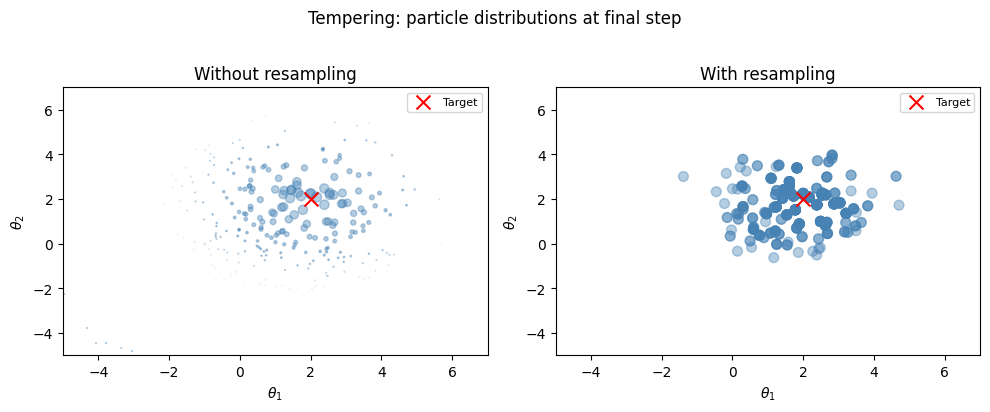

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, ds, title in [(axes[0], dists_no, 'Without resampling'), (axes[1], dists_yes, 'With resampling')]:
    final = ds[-1]
    s = np.array(final.samples)
    w = np.array(final.weights)
    sizes = w / w.max() * 50
    ax.scatter(s[:, 0], s[:, 1], s=sizes, alpha=0.4, c='steelblue')
    ax.scatter([2.0], [2.0], c='red', marker='x', s=100, zorder=5, label='Target')
    ax.set_xlim(-5, 7)
    ax.set_ylim(-5, 7)
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('Tempering: particle distributions at final step', y=1.02)
plt.tight_layout()
plt.show()

---

## 6. Custom Step Functions

A step function is any callable `(Distribution, input) -> Distribution`. No base class needed. Here's a minimal example:

In [11]:
def shift_step(dist, offset):
    """Shift all samples by an offset."""
    return EmpiricalDistribution(dist.samples + offset)

start = EmpiricalDistribution(jnp.zeros((200, 2)), name="start")
dists = iterate(shift_step, start, [1.0, 0.5, -0.3])

print(f"Steps:      {len(dists) - 1}")
print(f"Final mean: {mean(dists[-1])}")
print(f"Expected:   {1.0 + 0.5 - 0.3}")

Steps:      3
Final mean: NumericRecord(mean=array(shape=(2,)))
Expected:   1.2


---

## 7. Callbacks and Early Stopping

Pass a `callback` to `iterate` for logging or early termination. It receives `(step_index, distribution)` and returns `False` to stop.

In [12]:
def stop_when_converged(i, dist):
    m = float(jnp.mean(dist.samples))
    print(f"  Step {i}: mean = {m:.2f}")
    if m > 3.0:
        print(f"  -> Stopping (mean exceeded 3.0)")
        return False

start = EmpiricalDistribution(jnp.zeros((200, 2)))
dists = iterate(shift_step, start, [1.0, 1.5, 2.0, 2.5], callback=stop_when_converged)
print(f"Steps completed: {len(dists) - 1} of 4")

  Step 0: mean = 1.00
  Step 1: mean = 2.50
  Step 2: mean = 4.50
  -> Stopping (mean exceeded 3.0)
Steps completed: 3 of 4


---

## 8. Provenance Tracking

`iterate` automatically attaches provenance to each output distribution, linking it to the previous one. If a step function sets its own provenance, `iterate` respects it.

In [13]:
start = EmpiricalDistribution(jnp.zeros((100, 2)), name="start")
dists = iterate(shift_step, start, [1.0, 2.0, 3.0])

for i, d in enumerate(dists[1:]):
    src = d.source
    parent_name = src.parents[0].name or type(src.parents[0]).__name__
    print(f"  Step {i}: operation='{src.operation}', parent='{parent_name}'")

ancestors = provenance_ancestors(dists[-1])
print(f"\nAncestor chain: {[a.name or type(a).__name__ for a in ancestors]}")

  Step 0: operation='iterate', parent='start'
  Step 1: operation='iterate', parent='empirical'
  Step 2: operation='iterate', parent='empirical'

Ancestor chain: ['empirical', 'empirical', 'start']


---

## 9. Composing and Nesting

### Stacking combinators

Combinators compose by wrapping. Each returns a `WorkflowFunction`.

In [14]:
conditioner = IncrementalConditioner(
    prior=prior, likelihood=likelihood,
    condition_fn=gaussian_conjugate_condition,
)

composed_step = with_conversion(
    with_resampling(conditioner.step, ess_threshold=0.3),
    MultivariateNormal, name="posterior",
)

dists = iterate(composed_step, prior, batches)

print(f"All parametric: {all(isinstance(d, MultivariateNormal) for d in dists[1:])}")
print(f"Final mean:     {mean(dists[-1])}")
print(f"True mu:        {true_mu}")

All parametric: True
Final mean:     NumericRecord(mean=array(shape=(2,)))
True mu:        [ 2. -1.]


### Nested iteration

Step functions can call `iterate` internally — enabling algorithms like tempering-within-conditioning.

In [15]:
def inner_step(dist, value):
    return EmpiricalDistribution(dist.samples + value)

def outer_step(dist, batch):
    """Each outer step runs an inner iterate loop."""
    inner_dists = iterate(inner_step, dist, batch)
    return inner_dists[-1]

start = EmpiricalDistribution(jnp.zeros((100, 2)))
dists = iterate(outer_step, start, [[0.1, 0.2, 0.3], [0.4, 0.5]])

for i, d in enumerate(dists[1:]):
    m = float(jnp.mean(d.samples))
    print(f"  Outer {i}: mean={m:.2f}")

expected = 0.1 + 0.2 + 0.3 + 0.4 + 0.5
print(f"Final mean: {float(jnp.mean(dists[-1].samples)):.2f} (expected {expected:.2f})")

  Outer 0: mean=0.60
  Outer 1: mean=1.50
Final mean: 1.50 (expected 1.50)


---

## 10. Summary

| Component | What it does | When to use |
|-----------|-------------|-------------|
| `IncrementalConditioner` | Stateful sequential conditioning | Single-batch `update()` or multi-batch `update_all()` |
| `iterate` | Fold a step function over inputs | The core iteration primitive |
| `with_conversion` | Call `from_distribution` after each step | Keeping posteriors parametric between steps |
| `with_resampling` | Resample when ESS degenerates | Tempering, SMC, importance sampling |

**Key ideas:**

- A step function is any callable `(Distribution, input) -> Distribution`.
- `IncrementalConditioner` uses `condition_on` dispatch by default.
- `with_conversion` calls `from_distribution`, and the auto-conversion in the conditioning step uses the converter registry — these are the same systems used throughout ProbPipe.
- Combinators compose: `with_conversion(with_resampling(step, ...), ...)`.
- `iterate` is a `WorkflowFunction` — it participates in ProbPipe's orchestration like any other operation.
- Provenance tracks the full lineage through the iteration.